# v6: Conformal Prediction（予測集合による不確実性定量化）

**入力:**
- `results/models/v3a_val_predictions.npz` — CP calibration用（raw logits）
- `results/models/v3a_test_predictions.npz` — CP test用（raw logits）
- `results/v4_TS/temperature_v3a.json` — Temperature Scaling T値

**分割:** val全体 → CP calibration、test全体 → CP test
（3分割導入により独立したtest setを使用。旧版のval内部50/50分割は不要）

**手法:** Adaptive Prediction Sets (APS; Romano et al., NeurIPS 2020)

**参考文献:**
- Romano, Sesia, Candès. "Classification with Valid and Adaptive Coverage." NeurIPS 2020
- Angelopoulos & Bates. "A Gentle Introduction to Conformal Prediction." 2022


In [1]:
# ============================================================
# Cell 1: val/test npz + T読み込み → TS適用（GPU不要）
# ============================================================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from scipy.special import softmax
from sklearn.metrics import roc_auc_score, classification_report
from pathlib import Path

RESULTS_DIR = Path("../results/models")
V6_DIR      = Path("../results/v6")
V6_DIR.mkdir(exist_ok=True)

CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
NUM_CLASSES = len(CLASS_NAMES)
MEL_IDX = CLASS_NAMES.index('mel')
MALIGNANT_INDICES = [CLASS_NAMES.index(c) for c in ['mel', 'bcc', 'akiec']]

NB_NAME = 'v3a'

# --- val npz（CP calibration） ---
_val = np.load(RESULTS_DIR / f"{NB_NAME}_val_predictions.npz")
val_logits = _val["all_logits"]
y_cal      = _val["y_true"]

# --- test npz（CP test） ---
_test = np.load(RESULTS_DIR / f"{NB_NAME}_test_predictions.npz")
test_logits = _test["all_logits"]
y_test      = _test["y_true"]

# --- Temperature Scaling適用（メモリ上のみ） ---
with open(Path('../results/v4_TS/temperature_v3a.json')) as f:
    T = json.load(f)['temperature']

probs_cal  = softmax(val_logits / T, axis=1)
probs_test = softmax(test_logits / T, axis=1)

print(f"CP calibration (val): {len(y_cal)}")
print(f"  dist: {dict(zip(CLASS_NAMES, np.bincount(y_cal, minlength=NUM_CLASSES)))}")
print(f"CP test (test):       {len(y_test)}")
print(f"  dist: {dict(zip(CLASS_NAMES, np.bincount(y_test, minlength=NUM_CLASSES)))}")
print(f"T = {T:.4f}")


CP calibration (val): 551
  dist: {'akiec': np.int64(15), 'bcc': np.int64(17), 'bkl': np.int64(44), 'df': np.int64(4), 'mel': np.int64(23), 'nv': np.int64(441), 'vasc': np.int64(7)}
CP test (test):       552
  dist: {'akiec': np.int64(15), 'bcc': np.int64(18), 'bkl': np.int64(44), 'df': np.int64(4), 'mel': np.int64(23), 'nv': np.int64(442), 'vasc': np.int64(6)}
T = 1.4478


In [2]:
# ============================================================
# Cell 2: CP分割（不要 — 3分割で独立済み）
# ============================================================
"""
旧版ではval内部で50/50分割していたが、
v3a再訓練でtrain/val/test 3分割を導入したため、
val全体 = CP calibration、test全体 = CP test として使用。
"""
SEED = 42  # メタ情報用
print("val=CP_calibration, test=CP_test (independent 3-split)")


val=CP_calibration, test=CP_test (independent 3-split)


## Adaptive Prediction Sets (APS)

APS (Romano et al., NeurIPS 2020) のアルゴリズム：

1. **Nonconformity score計算:** 各サンプルについて、クラスを確率の降順にソートし、
   正解クラスが含まれるまでの累積確率をscoreとする
2. **分位点 q̂ の決定:** calibration setのscoreの `⌈(1-α)(n+1)⌉/n` 分位点を求める
3. **予測集合の生成:** test setの各サンプルについて、累積確率が q̂ を超えるまでクラスを含める

この手順により、`P(Y ∈ C(X)) ≥ 1 - α` が有限サンプルで保証される。

In [3]:
# ============================================================
# Cell 3: APS — Nonconformity Score と予測集合の関数定義
# ============================================================

def aps_nonconformity_score(probs, y):
    """
    APS nonconformity score: 確率降順で正解クラスが含まれるまでの累積確率。
    
    Args:
        probs: (N, K) calibrated確率
        y: (N,) 正解ラベル
    Returns:
        scores: (N,) nonconformity scores
    """
    N, K = probs.shape
    # 確率の降順ソート
    sorted_indices = np.argsort(-probs, axis=1)  # (N, K)
    sorted_probs = np.take_along_axis(probs, sorted_indices, axis=1)  # (N, K)
    cumsum_probs = np.cumsum(sorted_probs, axis=1)  # (N, K)
    
    # 正解クラスのソート後位置を特定
    scores = np.zeros(N)
    for i in range(N):
        rank = np.where(sorted_indices[i] == y[i])[0][0]
        scores[i] = cumsum_probs[i, rank]
    
    return scores


def aps_quantile(scores, alpha):
    """
    有限サンプル補正付き分位点: ⌈(n+1)(1-α)⌉ / n 番目のscore。
    """
    n = len(scores)
    q_level = np.ceil((n + 1) * (1 - alpha)) / n
    q_level = min(q_level, 1.0)  # 上限クリップ
    return np.quantile(scores, q_level, method='higher')


def aps_prediction_sets(probs, q_hat):
    """
    分位点 q_hat を使って予測集合を生成。
    
    Args:
        probs: (N, K) calibrated確率
        q_hat: nonconformity scoreの分位点
    Returns:
        sets: list of lists（各サンプルの予測集合）
    """
    N, K = probs.shape
    sorted_indices = np.argsort(-probs, axis=1)
    sorted_probs = np.take_along_axis(probs, sorted_indices, axis=1)
    cumsum_probs = np.cumsum(sorted_probs, axis=1)
    
    prediction_sets = []
    for i in range(N):
        # 累積確率が q_hat を超える最初の位置まで含める
        n_include = np.searchsorted(cumsum_probs[i], q_hat, side='left') + 1
        n_include = min(n_include, K)
        pred_set = sorted_indices[i, :n_include].tolist()
        prediction_sets.append(pred_set)
    
    return prediction_sets


print("APS関数定義完了 ✓")

APS関数定義完了 ✓


In [4]:
# ============================================================
# Cell 4: CPの実行（複数の信頼水準で比較）
# ============================================================
"""
臨床的に意味のある3つの信頼水準で実行:
  - 90%: 標準的な水準
  - 95%: mel見逃しを最小化する水準（推奨）
  - 99%: 保守的な水準（集合が大きくなりすぎないか確認）
"""

# Calibration setでnonconformity scoreを計算
cal_scores = aps_nonconformity_score(probs_cal, y_cal)

print(f"Calibration scores: min={cal_scores.min():.4f}, "
      f"median={np.median(cal_scores):.4f}, max={cal_scores.max():.4f}")
print()

ALPHAS = [0.10, 0.05, 0.01]
cp_results = {}

for alpha in ALPHAS:
    q_hat = aps_quantile(cal_scores, alpha)
    pred_sets = aps_prediction_sets(probs_test, q_hat)
    
    # カバレッジ（正解が集合に含まれる割合）
    coverage = np.mean([y_test[i] in pred_sets[i] for i in range(len(y_test))])
    
    # 集合サイズ
    set_sizes = np.array([len(s) for s in pred_sets])
    
    cp_results[alpha] = {
        'q_hat': q_hat,
        'pred_sets': pred_sets,
        'coverage': coverage,
        'set_sizes': set_sizes,
    }
    
    print(f"α={alpha:.2f} (信頼水準 {100*(1-alpha):.0f}%):")
    print(f"  q̂ = {q_hat:.4f}")
    print(f"  Coverage: {coverage:.4f} (目標: ≧{1-alpha:.2f})")
    print(f"  集合サイズ: mean={set_sizes.mean():.2f}, "
          f"median={np.median(set_sizes):.0f}, "
          f"min={set_sizes.min()}, max={set_sizes.max()}")
    size_dist = {k: int(v) for k, v in zip(*np.unique(set_sizes, return_counts=True))}
    print(f"  サイズ分布: {size_dist}")
    print()

Calibration scores: min=0.4550, median=0.9906, max=1.0000

α=0.10 (信頼水準 90%):
  q̂ = 0.9991
  Coverage: 1.0000 (目標: ≧0.90)
  集合サイズ: mean=3.16, median=3, min=1, max=7
  サイズ分布: {np.int64(1): 46, np.int64(2): 130, np.int64(3): 173, np.int64(4): 126, np.int64(5): 49, np.int64(6): 23, np.int64(7): 5}

α=0.05 (信頼水準 95%):
  q̂ = 0.9996
  Coverage: 1.0000 (目標: ≧0.95)
  集合サイズ: mean=3.60, median=4, min=1, max=7
  サイズ分布: {np.int64(1): 21, np.int64(2): 96, np.int64(3): 153, np.int64(4): 155, np.int64(5): 78, np.int64(6): 39, np.int64(7): 10}

α=0.01 (信頼水準 99%):
  q̂ = 1.0000
  Coverage: 1.0000 (目標: ≧0.99)
  集合サイズ: mean=4.90, median=5, min=1, max=7
  サイズ分布: {np.int64(1): 2, np.int64(2): 8, np.int64(3): 56, np.int64(4): 154, np.int64(5): 161, np.int64(6): 97, np.int64(7): 74}



In [5]:
# ============================================================
# Cell 5: 臨床分析 — mel安全性（α=0.05 を主分析）
# ============================================================
"""
臨床的に最も重要な問い:
「実際にmelである症例のうち、予測集合にmelが含まれている割合は？」

これはconformal coverageとは別の指標。coverageは全クラス平均だが、
ここではmelクラス単独のcoverageを見る。
"""

alpha_main = 0.05
r = cp_results[alpha_main]
pred_sets = r['pred_sets']

print(f"=== 臨床安全性分析（α={alpha_main}, 信頼水準 {100*(1-alpha_main):.0f}%） ===")
print()

# --- クラス別カバレッジ ---
print("クラス別カバレッジ（正解が集合に含まれる割合）:")
class_coverages = {}
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = y_test == cls_idx
    if mask.sum() == 0:
        continue
    cls_coverage = np.mean([y_test[i] in pred_sets[i] for i in range(len(y_test)) if mask[i]])
    class_coverages[cls_name] = cls_coverage
    marker = " ← 臨床最重要" if cls_name == 'mel' else ""
    print(f"  {cls_name}: {cls_coverage:.4f} (n={mask.sum()}){marker}")

print()

# --- mel症例の詳細分析 ---
mel_mask = y_test == MEL_IDX
mel_indices = np.where(mel_mask)[0]
n_mel = len(mel_indices)

mel_in_set = sum(MEL_IDX in pred_sets[i] for i in mel_indices)
mel_covered = sum(y_test[i] in pred_sets[i] for i in mel_indices)  # 同じだが明示

print(f"mel症例の詳細 (n={n_mel}):")
print(f"  正解(mel)が集合に含まれる: {mel_covered}/{n_mel} ({mel_covered/n_mel:.4f})")
print()

# --- 全症例でmelが集合に含まれる場合の分析 ---
mel_in_any = sum(MEL_IDX in pred_sets[i] for i in range(len(y_test)))
print(f"全test set ({len(y_test)}症例) でmelが予測集合に含まれる: {mel_in_any}症例")
print(f"  うち実際にmel: {mel_covered}")
print(f"  うちmel以外:   {mel_in_any - mel_covered}（過剰紹介になるケース）")
print()

# --- argmaxがmelを見逃すが、CPが拾うケース ---
argmax_preds = np.argmax(probs_test, axis=1)
mel_missed_by_argmax = np.sum((y_test == MEL_IDX) & (argmax_preds != MEL_IDX))
mel_missed_but_cp_catches = sum(
    1 for i in mel_indices
    if argmax_preds[i] != MEL_IDX and MEL_IDX in pred_sets[i]
)
print(f"argmaxがmelを見逃す症例: {mel_missed_by_argmax}/{n_mel}")
print(f"  うちCPの予測集合がmelを含む: {mel_missed_but_cp_catches}")
print(f"  → CPによる安全網で救済される症例数")

=== 臨床安全性分析（α=0.05, 信頼水準 95%） ===

クラス別カバレッジ（正解が集合に含まれる割合）:
  akiec: 1.0000 (n=15)
  bcc: 1.0000 (n=18)
  bkl: 1.0000 (n=44)
  df: 1.0000 (n=4)
  mel: 1.0000 (n=23) ← 臨床最重要
  nv: 1.0000 (n=442)
  vasc: 1.0000 (n=6)

mel症例の詳細 (n=23):
  正解(mel)が集合に含まれる: 23/23 (1.0000)

全test set (552症例) でmelが予測集合に含まれる: 460症例
  うち実際にmel: 23
  うちmel以外:   437（過剰紹介になるケース）

argmaxがmelを見逃す症例: 10/23
  うちCPの予測集合がmelを含む: 10
  → CPによる安全網で救済される症例数


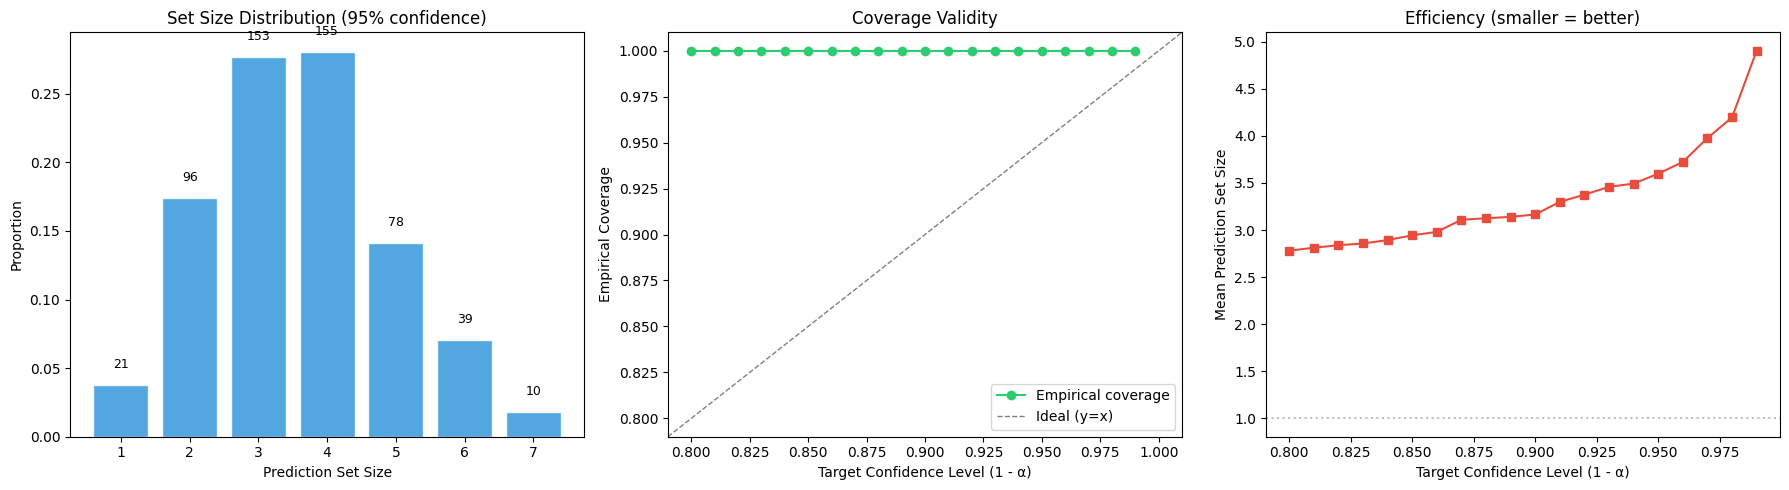

Saved: ../results/v6/fig_v6_cp_overview.png


In [6]:
# ============================================================
# Cell 6: 可視化 — 集合サイズ分布 + カバレッジ vs 信頼水準
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- (a) 集合サイズ分布（α=0.05） ---
ax = axes[0]
sizes = cp_results[0.05]['set_sizes']
unique_sizes, counts = np.unique(sizes, return_counts=True)
ax.bar(unique_sizes, counts / len(sizes), color='#3498db', alpha=0.85, edgecolor='white')
ax.set_xlabel('Prediction Set Size')
ax.set_ylabel('Proportion')
ax.set_title(f'Set Size Distribution (95% confidence)')
ax.set_xticks(range(1, NUM_CLASSES + 1))
for s, c in zip(unique_sizes, counts):
    ax.text(s, c / len(sizes) + 0.01, f'{c}', ha='center', va='bottom', fontsize=9)

# --- (b) カバレッジ vs 信頼水準 ---
ax = axes[1]
alphas_fine = np.arange(0.01, 0.21, 0.01)
coverages_fine = []
mean_sizes_fine = []
for a in alphas_fine:
    q = aps_quantile(cal_scores, a)
    ps = aps_prediction_sets(probs_test, q)
    cov = np.mean([y_test[i] in ps[i] for i in range(len(y_test))])
    ms = np.mean([len(s) for s in ps])
    coverages_fine.append(cov)
    mean_sizes_fine.append(ms)

confidence_levels = 1 - alphas_fine
ax.plot(confidence_levels, coverages_fine, 'o-', color='#2ecc71', label='Empirical coverage')
ax.plot([0.79, 1.01], [0.79, 1.01], 'k--', lw=1, alpha=0.5, label='Ideal (y=x)')
ax.set_xlabel('Target Confidence Level (1 - α)')
ax.set_ylabel('Empirical Coverage')
ax.set_title('Coverage Validity')
ax.legend(loc='lower right')
ax.set_xlim(0.79, 1.01)
ax.set_ylim(0.79, 1.01)

# --- (c) 平均集合サイズ vs 信頼水準 ---
ax = axes[2]
ax.plot(confidence_levels, mean_sizes_fine, 's-', color='#e74c3c')
ax.set_xlabel('Target Confidence Level (1 - α)')
ax.set_ylabel('Mean Prediction Set Size')
ax.set_title('Efficiency (smaller = better)')
ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(V6_DIR / 'fig_v6_cp_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {V6_DIR / 'fig_v6_cp_overview.png'}")

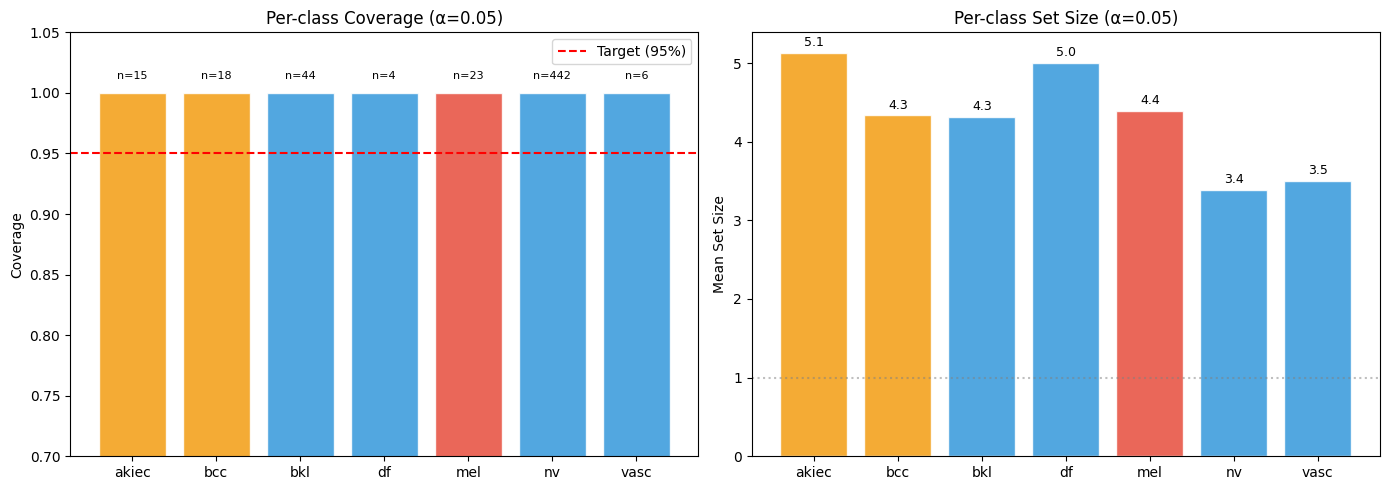

Saved: ../results/v6/fig_v6_cp_per_class.png


In [7]:
# ============================================================
# Cell 7: 可視化 — クラス別カバレッジ + 集合サイズ
# ============================================================

alpha_main = 0.05
r = cp_results[alpha_main]
pred_sets = r['pred_sets']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- (a) クラス別カバレッジ ---
ax = axes[0]
cls_names_plot = []
cls_covs_plot = []
cls_counts_plot = []
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = y_test == cls_idx
    if mask.sum() == 0:
        continue
    cov = np.mean([y_test[i] in pred_sets[i] for i in range(len(y_test)) if mask[i]])
    cls_names_plot.append(cls_name)
    cls_covs_plot.append(cov)
    cls_counts_plot.append(mask.sum())

colors = ['#e74c3c' if n == 'mel' else '#f39c12' if n in ['bcc', 'akiec'] else '#3498db'
          for n in cls_names_plot]
bars = ax.bar(cls_names_plot, cls_covs_plot, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(y=1-alpha_main, color='red', linestyle='--', lw=1.5,
           label=f'Target ({100*(1-alpha_main):.0f}%)')
ax.set_ylabel('Coverage')
ax.set_title(f'Per-class Coverage (α={alpha_main})')
ax.set_ylim(0.7, 1.05)
ax.legend()
for bar, cnt in zip(bars, cls_counts_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'n={cnt}', ha='center', va='bottom', fontsize=8)

# --- (b) クラス別平均集合サイズ ---
ax = axes[1]
cls_sizes_plot = []
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = y_test == cls_idx
    if mask.sum() == 0:
        cls_sizes_plot.append(0)
        continue
    mean_size = np.mean([len(pred_sets[i]) for i in range(len(y_test)) if mask[i]])
    cls_sizes_plot.append(mean_size)

bars = ax.bar(cls_names_plot, cls_sizes_plot, color=colors, alpha=0.85, edgecolor='white')
ax.set_ylabel('Mean Set Size')
ax.set_title(f'Per-class Set Size (α={alpha_main})')
ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
for bar, sz in zip(bars, cls_sizes_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{sz:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(V6_DIR / 'fig_v6_cp_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {V6_DIR / 'fig_v6_cp_per_class.png'}")

In [8]:
# ============================================================
# Cell 8: 具体例 — 予測集合の中身を表示
# ============================================================
"""
定時するための具体例を生成。
「典型的なケース」と「判断困難なケース」を対比する。
"""

alpha_main = 0.05
pred_sets = cp_results[alpha_main]['pred_sets']

print(f"=== 予測集合の具体例（α={alpha_main}） ===")
print()

# サイズ1（高確信）の例を最大3つ
print("--- 高確信（集合サイズ = 1）---")
size1_shown = 0
for i in range(len(y_test)):
    if len(pred_sets[i]) == 1 and size1_shown < 3:
        true_cls = CLASS_NAMES[y_test[i]]
        pred_cls = [CLASS_NAMES[c] for c in pred_sets[i]]
        top_prob = probs_test[i, pred_sets[i][0]]
        correct = '✓' if y_test[i] in pred_sets[i] else '✗'
        print(f"  Sample {i}: true={true_cls}, set={pred_cls}, "
              f"prob={top_prob:.3f} {correct}")
        size1_shown += 1

# mel症例で集合サイズ > 1 の例
print()
print("--- mel症例で判断困難（集合サイズ > 1）---")
mel_multi_shown = 0
for i in mel_indices:
    if len(pred_sets[i]) > 1 and mel_multi_shown < 3:
        true_cls = CLASS_NAMES[y_test[i]]
        pred_cls = [CLASS_NAMES[c] for c in pred_sets[i]]
        probs_sorted = [(CLASS_NAMES[c], probs_test[i, c]) for c in pred_sets[i]]
        probs_sorted.sort(key=lambda x: -x[1])
        prob_str = ', '.join([f'{n}:{p:.3f}' for n, p in probs_sorted])
        correct = '✓' if y_test[i] in pred_sets[i] else '✗'
        print(f"  Sample {i}: true={true_cls}, set={pred_cls} {correct}")
        print(f"    probs: {prob_str}")
        mel_multi_shown += 1

# argmaxが外すがCPが救うケース
print()
print("--- argmaxが見逃すがCPが救う mel 症例 ---")
rescue_shown = 0
for i in mel_indices:
    if argmax_preds[i] != MEL_IDX and MEL_IDX in pred_sets[i] and rescue_shown < 3:
        argmax_cls = CLASS_NAMES[argmax_preds[i]]
        pred_cls = [CLASS_NAMES[c] for c in pred_sets[i]]
        probs_sorted = [(CLASS_NAMES[c], probs_test[i, c]) for c in pred_sets[i]]
        probs_sorted.sort(key=lambda x: -x[1])
        prob_str = ', '.join([f'{n}:{p:.3f}' for n, p in probs_sorted])
        print(f"  Sample {i}: true=mel, argmax={argmax_cls}, CP set={pred_cls}")
        print(f"    probs: {prob_str}")
        print(f"    → argmaxだけなら見逃し、CPの予測集合にmelが含まれるため紹介対象")
        rescue_shown += 1

if rescue_shown == 0:
    print("  （該当症例なし）")

=== 予測集合の具体例（α=0.05） ===

--- 高確信（集合サイズ = 1）---
  Sample 4: true=nv, set=['nv'], prob=1.000 ✓
  Sample 8: true=nv, set=['nv'], prob=1.000 ✓
  Sample 15: true=akiec, set=['akiec'], prob=1.000 ✓

--- mel症例で判断困難（集合サイズ > 1）---
  Sample 5: true=mel, set=['bkl', 'mel', 'nv'] ✓
    probs: bkl:0.979, mel:0.011, nv:0.010
  Sample 16: true=mel, set=['mel', 'bkl', 'nv', 'akiec', 'bcc', 'df'] ✓
    probs: mel:0.476, bkl:0.289, nv:0.229, akiec:0.006, bcc:0.001, df:0.000
  Sample 52: true=mel, set=['akiec', 'mel', 'nv', 'bkl'] ✓
    probs: akiec:0.871, mel:0.073, nv:0.055, bkl:0.002

--- argmaxが見逃すがCPが救う mel 症例 ---
  Sample 5: true=mel, argmax=bkl, CP set=['bkl', 'mel', 'nv']
    probs: bkl:0.979, mel:0.011, nv:0.010
    → argmaxだけなら見逃し、CPの予測集合にmelが含まれるため紹介対象
  Sample 52: true=mel, argmax=akiec, CP set=['akiec', 'mel', 'nv', 'bkl']
    probs: akiec:0.871, mel:0.073, nv:0.055, bkl:0.002
    → argmaxだけなら見逃し、CPの予測集合にmelが含まれるため紹介対象
  Sample 150: true=mel, argmax=nv, CP set=['nv', 'mel', 'bkl']
    probs

In [9]:
# ============================================================
# Cell 9: 臨床的トリアージ判定 — CP集合ベース vs argmax vs 閾値
# ============================================================
"""
予測集合に基づくトリアージルール:
  集合に悪性(mel/bcc/akiec)が1つでも含まれる → 紹介
  集合が良性のみ → 経過観察

これをargmax判定と比較し、安全性の改善を定量化する。
"""

alpha_main = 0.05
pred_sets = cp_results[alpha_main]['pred_sets']

print(f"=== トリアージ比較（α={alpha_main}） ===")
print()

# 真のラベルが悪性かどうか
y_true_malignant = np.isin(y_test, MALIGNANT_INDICES)

# --- argmaxベース ---
argmax_refers = np.isin(argmax_preds, MALIGNANT_INDICES)
argmax_tp = np.sum(argmax_refers & y_true_malignant)   # 悪性を正しく紹介
argmax_fn = np.sum(~argmax_refers & y_true_malignant)  # 悪性を見逃し
argmax_fp = np.sum(argmax_refers & ~y_true_malignant)  # 良性を過剰紹介
argmax_sensitivity = argmax_tp / y_true_malignant.sum() if y_true_malignant.sum() > 0 else 0

# --- CPベース ---
cp_refers = np.array([any(c in MALIGNANT_INDICES for c in pred_sets[i])
                      for i in range(len(y_test))])
cp_tp = np.sum(cp_refers & y_true_malignant)
cp_fn = np.sum(~cp_refers & y_true_malignant)
cp_fp = np.sum(cp_refers & ~y_true_malignant)
cp_sensitivity = cp_tp / y_true_malignant.sum() if y_true_malignant.sum() > 0 else 0

print(f"{'Method':<25} {'Sensitivity':>12} {'Missed (FN)':>12} {'Over-refer (FP)':>16}")
print("-" * 65)
print(f"{'argmax':<25} {argmax_sensitivity:>12.4f} {argmax_fn:>12} {argmax_fp:>16}")
print(f"{'CP (α={alpha_main})':<25} {cp_sensitivity:>12.4f} {cp_fn:>12} {cp_fp:>16}")
print()

# mel単独
mel_argmax_sens = np.sum((argmax_preds == MEL_IDX) & (y_test == MEL_IDX)) / (y_test == MEL_IDX).sum()
mel_cp_sens = sum(MEL_IDX in pred_sets[i] for i in mel_indices) / len(mel_indices)

print(f"mel単独の検出率:")
print(f"  argmax: {mel_argmax_sens:.4f}")
print(f"  CP:     {mel_cp_sens:.4f}")
print(f"  改善:   +{mel_cp_sens - mel_argmax_sens:.4f}")

=== トリアージ比較（α=0.05） ===

Method                     Sensitivity  Missed (FN)  Over-refer (FP)
-----------------------------------------------------------------
argmax                          0.7143           16               19
CP (α={alpha_main})             1.0000            0              414

mel単独の検出率:
  argmax: 0.5652
  CP:     1.0000
  改善:   +0.4348


In [10]:
# ============================================================
# Cell 10: 結果の保存
# ============================================================

cp_summary = {}
for alpha in ALPHAS:
    r = cp_results[alpha]
    pred_sets = r['pred_sets']
    
    # クラス別カバレッジ
    per_class_cov = {}
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = y_test == cls_idx
        if mask.sum() > 0:
            per_class_cov[cls_name] = float(np.mean(
                [y_test[i] in pred_sets[i] for i in range(len(y_test)) if mask[i]]
            ))
    
    cp_summary[f'alpha_{alpha}'] = {
        'alpha': alpha,
        'confidence_level': 1 - alpha,
        'q_hat': float(r['q_hat']),
        'coverage': float(r['coverage']),
        'mean_set_size': float(r['set_sizes'].mean()),
        'median_set_size': float(np.median(r['set_sizes'])),
        'size_distribution': {int(k): int(v) for k, v in
                              zip(*np.unique(r['set_sizes'], return_counts=True))},
        'per_class_coverage': per_class_cov,
    }

# メタ情報追加
cp_summary['meta'] = {
    'model': NB_NAME,
    'temperature': T,
    'n_cal': len(y_cal),
    'n_test': len(y_test),
    'method': 'APS (Romano et al., NeurIPS 2020)',
    'seed': SEED,
    'split_note': 'val=CP_cal, test=CP_test (3-split)',
}

with open(V6_DIR / 'conformal_results.json', 'w') as f:
    json.dump(cp_summary, f, indent=2)

print(f"Saved: {V6_DIR / 'conformal_results.json'} ✓")

Saved: ../results/v6/conformal_results.json ✓


In [11]:
# ============================================================
# Cell 11: 実験ログ用テキスト出力
# ============================================================

r90 = cp_results[0.10]
r95 = cp_results[0.05]
r99 = cp_results[0.01]

# mel coverage at 95%
mel_cov_95 = class_coverages.get('mel', 0)

log_text = f"""
## v6: Conformal Prediction（E-1 / E-2 / E-3）

- 日時: (実行日を記入)
- 対象モデル: `models/densenet_v3a_*.pth`（最終モデル）
- ファイル: `src/v6.ipynb`
- 手法: Adaptive Prediction Sets (APS; Romano et al., NeurIPS 2020)
- calibrated確率使用（Temperature Scaling T={T:.4f}）
- 分割: val=calibration {len(y_cal)} / test {len(y_test)}（層化、seed={SEED}）

### E-1: カバレッジと集合サイズ

| 信頼水準 | α    | q̂     | Coverage | Mean Size | Median Size |
| -------- | ---- | ------ | -------- | --------- | ----------- |
| 90%      | 0.10 | {r90['q_hat']:.4f} | {r90['coverage']:.4f}   | {r90['set_sizes'].mean():.2f}      | {np.median(r90['set_sizes']):.0f}          |
| 95%      | 0.05 | {r95['q_hat']:.4f} | {r95['coverage']:.4f}   | {r95['set_sizes'].mean():.2f}      | {np.median(r95['set_sizes']):.0f}          |
| 99%      | 0.01 | {r99['q_hat']:.4f} | {r99['coverage']:.4f}   | {r99['set_sizes'].mean():.2f}      | {np.median(r99['set_sizes']):.0f}          |

### E-2: mel安全性（α=0.05）

| 指標 | 値 |
| ---- | -- |
| mel class coverage | {mel_cov_95:.4f} |
| argmax mel recall | {mel_argmax_sens:.4f} |
| CP mel detection | {mel_cp_sens:.4f} |
| argmax見逃し→CP救済 | {mel_missed_but_cp_catches}/{mel_missed_by_argmax} |

### E-3: トリアージ比較（悪性紹介判定、α=0.05）

| Method | Sensitivity | Missed (FN) | Over-refer (FP) |
| ------ | ----------- | ----------- | --------------- |
| argmax | {argmax_sensitivity:.4f} | {argmax_fn} | {argmax_fp} |
| CP     | {cp_sensitivity:.4f} | {cp_fn} | {cp_fp} |
"""

print(log_text)

with open(V6_DIR / 'experiment_log_v6.md', 'w') as f:
    f.write(log_text)
print(f'Saved: {V6_DIR}/experiment_log_v6.md')


## v6: Conformal Prediction（E-1 / E-2 / E-3）

- 日時: (実行日を記入)
- 対象モデル: `models/densenet_v3a_*.pth`（最終モデル）
- ファイル: `src/v6.ipynb`
- 手法: Adaptive Prediction Sets (APS; Romano et al., NeurIPS 2020)
- calibrated確率使用（Temperature Scaling T=1.4478）
- 分割: val=calibration 551 / test 552（層化、seed=42）

### E-1: カバレッジと集合サイズ

| 信頼水準 | α    | q̂     | Coverage | Mean Size | Median Size |
| -------- | ---- | ------ | -------- | --------- | ----------- |
| 90%      | 0.10 | 0.9991 | 1.0000   | 3.16      | 3          |
| 95%      | 0.05 | 0.9996 | 1.0000   | 3.60      | 4          |
| 99%      | 0.01 | 1.0000 | 1.0000   | 4.90      | 5          |

### E-2: mel安全性（α=0.05）

| 指標 | 値 |
| ---- | -- |
| mel class coverage | 1.0000 |
| argmax mel recall | 0.5652 |
| CP mel detection | 1.0000 |
| argmax見逃し→CP救済 | 10/10 |

### E-3: トリアージ比較（悪性紹介判定、α=0.05）

| Method | Sensitivity | Missed (FN) | Over-refer (FP) |
| ------ | ----------- | ----------- | --------------- |
| argmax | 0.7143 | 16 | 19 |
| CP     | 1.0